# import

In [39]:
import sys
sys.path.append('..')
import numpy as np
from collections import defaultdict
from StatTools.generators.ndfnoise_generator import ndfnoise
# from StatTools.generators.multi_scale_fractional_generator import MultiScaleFractionalGenerator
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
import plotly.express as px
from nmot import NMOT

def gen_traj(frame_num: int, ants_num: int, frame_shape: tuple, margin:int = 10,
             hurst_move: float = 0.5, hurst_species: float = 0.5, 
             start_point = None):

    dx = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)
    dy = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)

    x = dx.cumsum(axis=0).round().astype(np.int32)
    y = dy.cumsum(axis=0).round().astype(np.int32)

    if start_point is None:
        start_x = np.random.randint(-margin, frame_shape[1] + margin, (ants_num,))
        start_y = np.random.randint(-margin, frame_shape[0] + margin, (ants_num,))
        start_point = np.stack([start_x, start_y], axis=1)

    trajectories = np.stack([x, y], axis=2)
    trajectories = trajectories + start_point

    return trajectories

In [40]:
class KalmanPredictorCV():
    def __init__(self):
        self.kf_states = {}

    def _init_kf(self, pos):
        kf = cv.KalmanFilter(dynamParams = 4, measureParams = 2)
        kf.measurementMatrix = np.array([[1,0,0,0],
                                         [0,1,0,0]], np.float32)

        kf.transitionMatrix = np.array([[1,0,1,0],
                                        [0,1,0,1], 
                                        [0,0,1,0], 
                                        [0,0,0,1]], np.float32)

        kf.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-2 
        kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e-1
        kf.statePost = np.array([[pos[0]], [pos[1]], [0], [0]], np.float32)

        return kf
    
    def predict_update(self, tracks):
        predictions = []
        for tid in range(tracks.shape[1]):
            kf = self.kf_states[tid]
            x_pred, y_pred, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(tracks[0][tid][0])], [np.float32(tracks[0][tid][1])]], np.float32))
            predictions[tid] = [*x_pred, *y_pred]
            
        return predictions


# few tracks

In [ ]:
np.random.seed(42)
hurst_move = 0.5
traj = gen_traj(frame_num=10000, 
                ants_num=1, 
                frame_shape=(500, 500), 
                margin = -10,
                hurst_move = hurst_move,
                hurst_species = 0.5, 
                start_point = None)


In [ ]:
kp = KalmanPredictorCV()
kf_dict = {}
for tid in range(traj.shape[1]):
    kf_dict[tid] = kp._init_kf(traj[0, tid])

from collections import defaultdict
predictions = defaultdict(list)
for tid in range(traj.shape[1]):
    
    kf = kf_dict[tid]
    for detections in traj[1:, tid, :]:
        x_pred, y_pred, _, _ = kf.predict()
        kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
        predictions[tid].append([*x_pred, *y_pred])
        
kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(traj[1:200,0,0], label=f'fBm H:{hurst_move}')
plt.plot(kalman_preds[:200,0,0], label=f'fBm H:{hurst_move}')
plt.savefig(f'../data/artifacts/fgn_{hurst_move}_kalman_preds_lowscale.svg')
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(traj[1:,0,0])
plt.plot(kalman_preds[:,0,0])
plt.savefig(f'../data/artifacts/fgn_{hurst_move}_kalman_preds_highscale.svg')
plt.show()

fig, ax = plt.subplots()
fig.set_size_inches((15, 5))
# ax[0].plot(traj[1:,0,0]-kalman_preds[:,0,0])
ax.plot(traj[1:,0,1]-kalman_preds[:,0,1])
plt.savefig(f'../data/artifacts/fgn_{hurst_move}_kalman_error.svg')
plt.show()


In [ ]:

rmse = np.sqrt(np.mean((traj[1:]-kalman_preds)**2))
mse = np.mean((traj[1:]-kalman_preds)**2)
print(f'{rmse=:.4f}')
print(f'{mse=:.4f}')

# rmse vs hurst

In [ ]:
hurst_dict = {}
for hurst in np.arange(0.1, 2.0, 0.1):
    np.random.seed(42)
    traj = gen_traj(frame_num=1000, 
                    ants_num=300, 
                    frame_shape=(500, 500), 
                    margin = -10,
                    hurst_move = hurst,
                    hurst_species = 0.5, 
                    start_point = None)
    kp = KalmanPredictorCV()
    kf_dict = {}
    for tid in range(traj.shape[1]):
        kf_dict[tid] = kp._init_kf(traj[0, tid])

    from collections import defaultdict
    predictions = defaultdict(list)
    for tid in range(traj.shape[1]):
        
        kf = kf_dict[tid]
        for detections in traj[1:, tid, :]:
            x_pred, y_pred, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
            predictions[tid].append([*x_pred, *y_pred])
            
    kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))
    rmse = np.mean(np.sqrt(np.mean((traj[1:]-kalman_preds)**2, axis=0)), axis=1)
    hurst_dict[hurst.round(1)] = rmse

In [ ]:
hurst_df = pd.DataFrame(hurst_dict)

In [ ]:
# plt.figure(figsize = (15, 5))
# sns.kdeplot(hurst_df, palette='viridis')
# plt.xlabel('RMSE')
# plt.ylabel('')
# plt.show()

plt.figure(figsize = (15, 5))
sns.violinplot(hurst_df, native_scale=True, color='xkcd:sky blue')
plt.plot(hurst_df.median(), linestyle = '--')
plt.ylabel('RMSE')
plt.xlabel('H')

plt.grid()

fig_box = plt.figure(figsize = (15, 5))
sns.boxplot(hurst_df, native_scale=True, color='.3', fill=False, linewidth=.75, showfliers=False)
plt.plot(hurst_df.median(), linestyle = '--', color='.3')
plt.ylabel('RMSE')
plt.xlabel('H')
plt.grid()
plt.savefig('../data/artifacts/kalman_cv_vs_fgn_H_value.svg')

# AR velocity model

## defs

In [41]:
def compute_ar_coefficients(H, order=2):
            
    beta = 2 * H - 1
    
    a = [1.0]  # a_0 = 1
    for k in range(1, order + 1):
        a_k = (k - 1 - beta / 2) * a[-1] / k
        a.append(a_k)
    
    return a[1:]

In [42]:
class KalmanPredictorAR1():
    def __init__(self):
        self.kf_states = {}

    def _init_kf(self, pos, hurst):
        a1, a2 = compute_ar_coefficients(hurst, order=2)
        kf = cv.KalmanFilter(dynamParams = 4, measureParams = 2)
        kf.measurementMatrix = np.array([[1,0,0,0],
                                         [0,1,0,0]], np.float32)

        kf.transitionMatrix = np.array([[1, 0, -a1, 0],
                                        [0, 1, 0, -a1], 
                                        [0, 0, -a1, 0], 
                                        [0, 0, 0, -a1]], np.float32)

        kf.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-2 
        kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e-1
        kf.statePost = np.array([[pos[0]], [pos[1]], [0], [0]], np.float32)

        return kf
    
    def predict_update(self, tracks):
        predictions = []
        for tid in range(tracks.shape[1]):
            kf = self.kf_states[tid]
            x_pred, y_pred, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(tracks[0][tid][0])], [np.float32(tracks[0][tid][1])]], np.float32))
            predictions[tid] = [*x_pred, *y_pred]
            
        return predictions

class KalmanPredictorAR1_bad():
    def __init__(self):
        self.kf_states = {}

    def _init_kf(self, pos, hurst):
        a1, a2 = compute_ar_coefficients(hurst, order=2)
        kf = cv.KalmanFilter(dynamParams = 4, measureParams = 2)
        kf.measurementMatrix = np.array([[1,0,0,0],
                                         [0,1,0,0]], np.float32)

        kf.transitionMatrix = np.array([[1, 0, 1, 0],
                                        [0, 1, 0, 1], 
                                        [0, 0, -a1, 0], 
                                        [0, 0, 0, -a1]], np.float32)

        kf.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-2 
        kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e-1
        kf.statePost = np.array([[pos[0]], [pos[1]], [0], [0]], np.float32)

        return kf
    
    def predict_update(self, tracks):
        predictions = []
        for tid in range(tracks.shape[1]):
            kf = self.kf_states[tid]
            x_pred, y_pred, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(tracks[0][tid][0])], [np.float32(tracks[0][tid][1])]], np.float32))
            predictions[tid] = [*x_pred, *y_pred]
            
        return predictions
    
class KalmanPredictorAR2():
    def __init__(self):
        self.kf_states = {}

    def _init_kf(self, pos, hurst):
        a1, a2 = compute_ar_coefficients(hurst, order=2)
        kf = cv.KalmanFilter(dynamParams = 6, measureParams = 2)
        kf.measurementMatrix = np.array([[1,0,0,0,0,0],
                                         [0,1,0,0,0,0]], np.float32)

        kf.transitionMatrix = np.array([
            [1, 0, -a1-a2,      0,      a2,     0],     # x_k = x_{k-1} + (-a1-a2)*dx_{k-1} + a2*d2x_{k-1}
            [0, 1,  0,      -a1-a2,     0,      a2],    # y_k = y_{k-1} + (-a1-a2)*dy_{k-1} + a2*d2y_{k-1}
            [0, 0, -a1-a2,      0,      a2,     0],     # dx_k =          (-a1-a2)*dx_{k-1} + a2*d2x_{k-1}
            [0, 0,  0,      -a1-a2,     0,      a2],    # dy_k =          (-a1-a2)*dy_{k-1} + a2*d2y_{k-1}
            [0, 0, -a1-a2-1,    0,      a2,     0],     # d2x_k =       (-a1-a2-1)*dx_{k-1} + a2*d2x_{k-1}
            [0, 0,  0,      -a1-a2-1,   0,      a2],    # d2y_k =       (-a1-a2-1)*dy_{k-1} + a2*d2y_{k-1}
        ], dtype=np.float32)

        kf.processNoiseCov = np.eye(6, dtype=np.float32) * 1e-2
        kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e-1
        kf.statePost = np.array([[pos[0]], [pos[1]], [0], [0], [0], [0]], np.float32)

        return kf
    
    def predict_update(self, tracks):
        predictions = []
        for tid in range(tracks.shape[1]):
            kf = self.kf_states[tid]
            x_pred, y_pred, _, _, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(tracks[0][tid][0])], [np.float32(tracks[0][tid][1])]], np.float32))
            predictions[tid] = [*x_pred, *y_pred]
            
        return predictions
    
class KalmanPredictorAR3():
    def __init__(self):
        self.kf_states = {}

    def _init_kf(self, pos, hurst):
        a1, a2, a3 = compute_ar_coefficients(hurst, order=3)
        kf = cv.KalmanFilter(dynamParams = 8, measureParams = 2)
        kf.measurementMatrix = np.array([[1,0,0,0,0,0,0,0],
                                         [0,1,0,0,0,0,0,0]], np.float32)

        kf.transitionMatrix = np.array([
            [1, 0, -a1-a2-a3,       0,         a2+2*a3,        0,      -a3,    0   ],   # x_k   = x_{k-1} + (-a1-a2-a3)*dx_{k-1} +    (a2+2a3)*d2x_{k-1} - a3*d3x_{k-1}
            [0, 1,      0,        -a1-a2-a3,      0,      a2+2*a3,      0,    -a3 ],    # y_k   = y_{k-1} + (-a1-a2-a3)*dy_{k-1} +    (a2+2a3)*d2y_{k-1} - a3*d3y_{k-1}
            [0, 0, -a1-a2-a3,       0,         a2+2*a3,        0,      -a3,    0   ],   # dx_k  =           (-a1-a2-a3)*dx_{k-1} +    (a2+2a3)*d2x_{k-1} - a3*d3x_{k-1}
            [0, 0,      0,        -a1-a2-a3,      0,      a2+2*a3,      0,    -a3 ],    # dy_k  =           (-a1-a2-a3)*dy_{k-1} +    (a2+2a3)*d2y_{k-1} - a3*d3y_{k-1}
            [0, 0, -1-a1-a2-a3,     0,         a2+2*a3,        0,      -a3,    0   ],   # d2x_k =         (-1-a1-a2-a3)*dx_{k-1} +    (a2+2a3)*d2x_{k-1} - a3*d3x_{k-1}
            [0, 0,      0,      -1-a1-a2-a3,    0,      a2+2*a3,      0,    -a3 ],      # d2y_k =         (-1-a1-a2-a3)*dy_{k-1} +    (a2+2a3)*d2y_{k-1} - a3*d3y_{k-1}
            [0, 0, -1-a1-a2-a3,     0,      -1+a2+2*a3,     0,       -a3,    0  ],      # d3x_k =         (-1-a1-a2-a3)*dx_{k-1} + (-1+a2+2a3)*d2x_{k-1} - a3*d3x_{k-1}
            [0, 0,      0,      -1-a1-a2-a3,     0,    -1+a2+2*a3,    0,    -a3 ]       # d3y_k =         (-1-a1-a2-a3)*dy_{k-1} + (-1+a2+2a3)*d2y_{k-1} - a3*d3y_{k-1}
        ], dtype=np.float32)
        
        # q = 0.8 ** 2

        # Q = q * np.array([
        #     [1, 0, 1, 0, 1, 0, 1, 0],
        #     [0, 1, 0, 1, 0, 1, 0, 1],
        #     [0, 0, 1, 0, 1, 0, 1, 0],
        #     [0, 0, 0, 1, 0, 1, 0, 1],
        #     [0, 0, 1, 0, 1, 0, 1, 0],
        #     [0, 0, 0, 1, 0, 1, 0, 1],
        #     [0, 0, 1, 0, 1, 0, 1, 0],
        #     [0, 0, 0, 1, 0, 1, 0, 1],
        # ], dtype=np.float32)

        kf.processNoiseCov = np.eye(8, dtype=np.float32) * 1e-2
        kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e-1
        kf.statePost = np.array([[pos[0]], [pos[1]], [0], [0], [0], [0], [0], [0]], np.float32)

        return kf
    
    def predict_update(self, tracks):
        predictions = []
        for tid in range(tracks.shape[1]):
            kf = self.kf_states[tid]
            x_pred, y_pred, _, _, _, _, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(tracks[0][tid][0])], [np.float32(tracks[0][tid][1])]], np.float32))
            predictions[tid] = [*x_pred, *y_pred]
            
        return predictions


## Constant velocity


In [43]:
hurst_dict_cv = {}
for hurst in np.arange(0.1, 2.0, 0.1):
    np.random.seed(42)
    traj = gen_traj(frame_num=1000, 
                    ants_num=300, 
                    frame_shape=(500, 500), 
                    margin = -10,
                    hurst_move = hurst,
                    hurst_species = 0.5, 
                    start_point = None)
    kp = KalmanPredictorCV()
    kf_dict = {}
    for tid in range(traj.shape[1]):
        kf_dict[tid] = kp._init_kf(traj[0, tid])

    from collections import defaultdict
    predictions = defaultdict(list)
    for tid in range(traj.shape[1]):
        
        kf = kf_dict[tid]
        for detections in traj[1:, tid, :]:
            x_pred, y_pred, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
            predictions[tid].append([*x_pred, *y_pred])
            
    kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))
    rmse = np.mean(np.sqrt(np.mean((traj[1:]-kalman_preds)**2, axis=0)), axis=1)
    hurst_dict_cv[hurst.round(1)] = rmse

/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning:

divide by zero encountered in power

/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning:

divide by zero encountered in reciprocal



In [44]:
hurst_df_cv = pd.DataFrame(hurst_dict_cv)

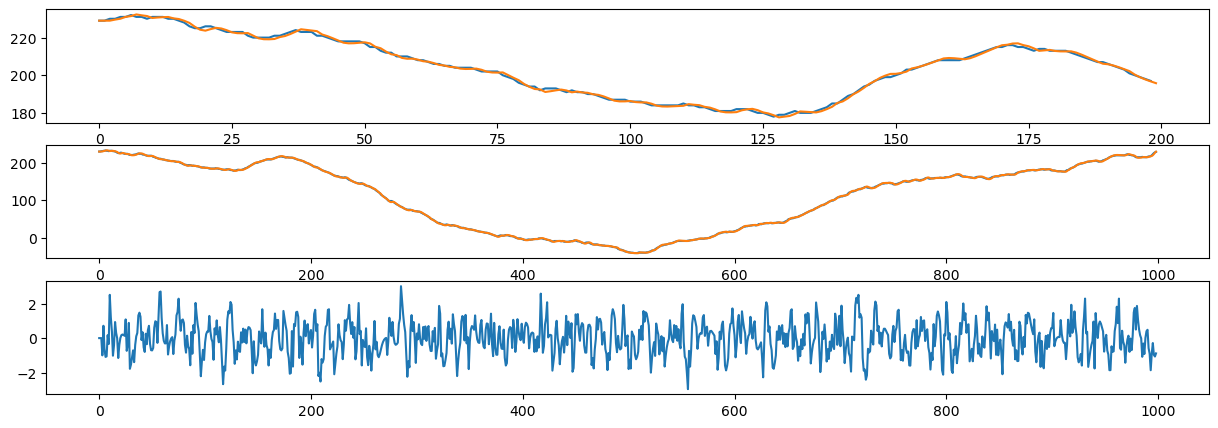

In [45]:
hurst = 1.0
traj = gen_traj(frame_num=1000, 
                ants_num=1, 
                frame_shape=(500, 500), 
                margin = -10,
                hurst_move = hurst,
                hurst_species = 0.5, 
                start_point = None)
kp = KalmanPredictorCV()
kf_dict = {}
for tid in range(traj.shape[1]):
    kf_dict[tid] = kp._init_kf(traj[0, tid])


predictions = defaultdict(list)
for tid in range(traj.shape[1]):
    
    kf = kf_dict[tid]
    for detections in traj[1:, tid, :]:
        x_pred, y_pred, _, _ = kf.predict()
        kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
        predictions[tid].append([*x_pred, *y_pred])
        
kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))
rmse = np.mean(np.sqrt(np.mean((traj[1:]-kalman_preds)**2, axis=0)), axis=1)

fig, axes = plt.subplots(nrows=3)
axes = axes.flatten()
fig.set_size_inches((15, 5))
axes[0].plot(traj[1:200,0,0], label=f'fBm H:{hurst}')
axes[0].plot(kalman_preds[:200,0,0], label=f'fBm H:{hurst}')
axes[1].plot(traj[1:,0,0])
axes[1].plot(kalman_preds[:,0,0])
axes[2].plot(traj[1:,0,1]-kalman_preds[:,0,1])

plt.show()


## AR1

In [46]:
hurst_dict_ar1 = {}
for hurst in np.arange(0.1, 2.0, 0.1):
    np.random.seed(42)
    traj = gen_traj(frame_num=1000, 
                    ants_num=300, 
                    frame_shape=(500, 500), 
                    margin = -10,
                    hurst_move = hurst,
                    hurst_species = 0.5, 
                    start_point = None)
    kp = KalmanPredictorAR1()
    kf_dict = {}
    for tid in range(traj.shape[1]):
        kf_dict[tid] = kp._init_kf(traj[0, tid], hurst=hurst)

    
    predictions = defaultdict(list)
    for tid in range(traj.shape[1]):
        
        kf = kf_dict[tid]
        for detections in traj[1:, tid, :]:
            x_pred, y_pred, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
            predictions[tid].append([*x_pred, *y_pred])
            
    kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))
    rmse = np.mean(np.sqrt(np.mean((traj[1:]-kalman_preds)**2, axis=0)), axis=1)
    hurst_dict_ar1[hurst.round(1)] = rmse


In [47]:
hurst_df_ar1 = pd.DataFrame(hurst_dict_ar1)

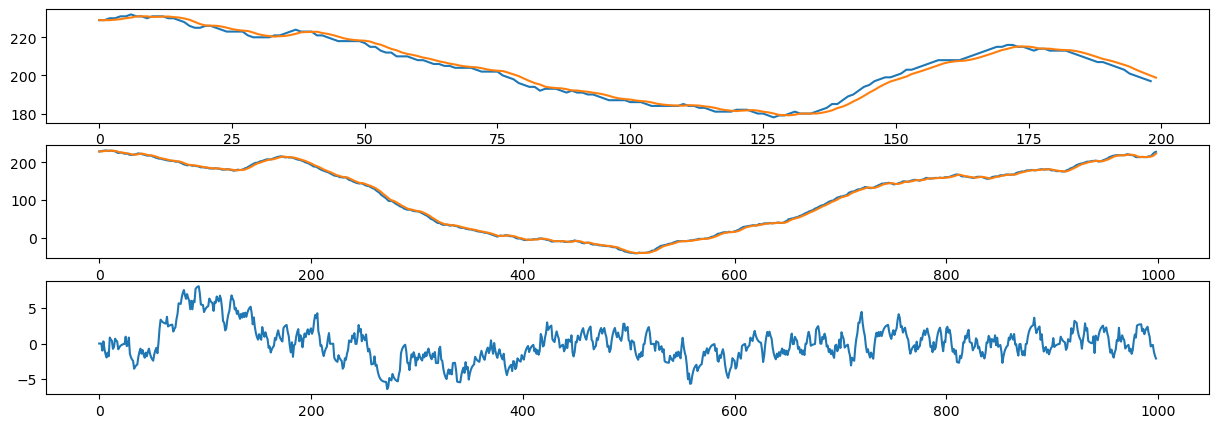

In [48]:
hurst = 1.0
traj = gen_traj(frame_num=1000, 
                ants_num=1, 
                frame_shape=(500, 500), 
                margin = -10,
                hurst_move = hurst,
                hurst_species = 0.5, 
                start_point = None)
kp = KalmanPredictorAR1()
kf_dict = {}
for tid in range(traj.shape[1]):
    kf_dict[tid] = kp._init_kf(traj[0, tid], hurst=hurst)


predictions = defaultdict(list)
for tid in range(traj.shape[1]):
    
    kf = kf_dict[tid]
    for detections in traj[1:, tid, :]:
        x_pred, y_pred, _, _ = kf.predict()
        kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
        predictions[tid].append([*x_pred, *y_pred])
        
kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))
rmse = np.mean(np.sqrt(np.mean((traj[1:]-kalman_preds)**2, axis=0)), axis=1)

fig, axes = plt.subplots(nrows=3)
axes = axes.flatten()
fig.set_size_inches((15, 5))
axes[0].plot(traj[1:200,0,0], label=f'fBm H:{hurst}')
axes[0].plot(kalman_preds[:200,0,0], label=f'fBm H:{hurst}')
axes[1].plot(traj[1:,0,0])
axes[1].plot(kalman_preds[:,0,0])
axes[2].plot(traj[1:,0,1]-kalman_preds[:,0,1])

plt.show()


## AR1 incorrect

In [ ]:
hurst_dict_ar1_bad = {}
for hurst in np.arange(0.1, 2.0, 0.1):
    np.random.seed(42)
    traj = gen_traj(frame_num=1000, 
                    ants_num=300, 
                    frame_shape=(500, 500), 
                    margin = -10,
                    hurst_move = hurst,
                    hurst_species = 0.5, 
                    start_point = None)
    kp = KalmanPredictorAR1_bad()
    kf_dict = {}
    for tid in range(traj.shape[1]):
        kf_dict[tid] = kp._init_kf(traj[0, tid], hurst=hurst)

    
    predictions = defaultdict(list)
    for tid in range(traj.shape[1]):
        
        kf = kf_dict[tid]
        for detections in traj[1:, tid, :]:
            x_pred, y_pred, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
            predictions[tid].append([*x_pred, *y_pred])
            
    kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))
    rmse = np.mean(np.sqrt(np.mean((traj[1:]-kalman_preds)**2, axis=0)), axis=1)
    hurst_dict_ar1_bad[hurst.round(1)] = rmse


In [ ]:
hurst_df_ar1_bad = pd.DataFrame(hurst_dict_ar1_bad)

In [ ]:
hurst = 1.0
traj = gen_traj(frame_num=1000, 
                ants_num=1, 
                frame_shape=(500, 500), 
                margin = -10,
                hurst_move = hurst,
                hurst_species = 0.5, 
                start_point = None)
kp = KalmanPredictorAR1_bad()
kf_dict = {}
for tid in range(traj.shape[1]):
    kf_dict[tid] = kp._init_kf(traj[0, tid], hurst=hurst)


predictions = defaultdict(list)
for tid in range(traj.shape[1]):
    
    kf = kf_dict[tid]
    for detections in traj[1:, tid, :]:
        x_pred, y_pred, _, _ = kf.predict()
        kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
        predictions[tid].append([*x_pred, *y_pred])
        
kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))
rmse = np.mean(np.sqrt(np.mean((traj[1:]-kalman_preds)**2, axis=0)), axis=1)

fig, axes = plt.subplots(nrows=3)
axes = axes.flatten()
fig.set_size_inches((15, 5))
axes[0].plot(traj[1:200,0,0], label=f'fBm H:{hurst}')
axes[0].plot(kalman_preds[:200,0,0], label=f'fBm H:{hurst}')
axes[1].plot(traj[1:,0,0])
axes[1].plot(kalman_preds[:,0,0])
axes[2].plot(traj[1:,0,1]-kalman_preds[:,0,1])

plt.show()


## AR2

In [49]:
hurst_dict_ar2 = {}
for hurst in np.arange(0.1, 2.0, 0.1):
    np.random.seed(42)
    traj = gen_traj(frame_num=1000, 
                    ants_num=300, 
                    frame_shape=(500, 500), 
                    margin = -10,
                    hurst_move = hurst,
                    hurst_species = 0.5, 
                    start_point = None)
    kp = KalmanPredictorAR2()
    kf_dict = {}
    for tid in range(traj.shape[1]):
        kf_dict[tid] = kp._init_kf(traj[0, tid], hurst=hurst)

    
    predictions = defaultdict(list)
    for tid in range(traj.shape[1]):
        
        kf = kf_dict[tid]
        for detections in traj[1:, tid, :]:
            x_pred, y_pred, _, _, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
            predictions[tid].append([*x_pred, *y_pred])
            
    kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))
    rmse = np.mean(np.sqrt(np.mean((traj[1:]-kalman_preds)**2, axis=0)), axis=1)
    hurst_dict_ar2[hurst.round(1)] = rmse


In [50]:
hurst_df_ar2 = pd.DataFrame(hurst_dict_ar2)

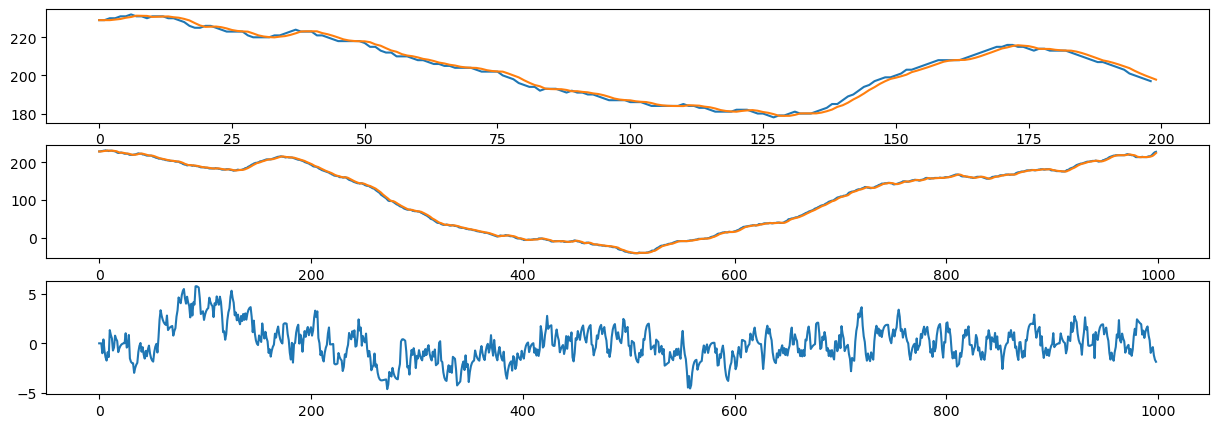

In [51]:
hurst = 1.0
traj = gen_traj(frame_num=1000, 
                ants_num=1, 
                frame_shape=(500, 500), 
                margin = -10,
                hurst_move = hurst,
                hurst_species = 0.5, 
                start_point = None)
kp = KalmanPredictorAR2()
kf_dict = {}
for tid in range(traj.shape[1]):
    kf_dict[tid] = kp._init_kf(traj[0, tid], hurst=hurst)


predictions = defaultdict(list)
for tid in range(traj.shape[1]):
    
    kf = kf_dict[tid]
    for detections in traj[1:, tid, :]:
        x_pred, y_pred, _, _, _, _ = kf.predict()
        kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
        predictions[tid].append([*x_pred, *y_pred])
        
kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))
rmse = np.mean(np.sqrt(np.mean((traj[1:]-kalman_preds)**2, axis=0)), axis=1)

fig, axes = plt.subplots(nrows=3)
axes = axes.flatten()
fig.set_size_inches((15, 5))
axes[0].plot(traj[1:200,0,0], label=f'fBm H:{hurst}')
axes[0].plot(kalman_preds[:200,0,0], label=f'fBm H:{hurst}')
axes[1].plot(traj[1:,0,0])
axes[1].plot(kalman_preds[:,0,0])
axes[2].plot(traj[1:,0,1]-kalman_preds[:,0,1])

plt.show()


## AR3

In [52]:
hurst_dict_ar3 = {}
for hurst in np.arange(0.1, 2.0, 0.1):
    np.random.seed(42)
    traj = gen_traj(frame_num=1000, 
                    ants_num=300, 
                    frame_shape=(500, 500), 
                    margin = -10,
                    hurst_move = hurst,
                    hurst_species = 0.5, 
                    start_point = None)
    kp = KalmanPredictorAR3()
    kf_dict = {}
    for tid in range(traj.shape[1]):
        kf_dict[tid] = kp._init_kf(traj[0, tid], hurst=hurst)

    
    predictions = defaultdict(list)
    for tid in range(traj.shape[1]):
        
        kf = kf_dict[tid]
        for detections in traj[1:, tid, :]:
            x_pred, y_pred, _, _, _, _, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
            predictions[tid].append([*x_pred, *y_pred])
            
    kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))
    rmse = np.mean(np.sqrt(np.mean((traj[1:]-kalman_preds)**2, axis=0)), axis=1)
    hurst_dict_ar3[hurst.round(1)] = rmse


In [53]:
hurst_df_ar3 = pd.DataFrame(hurst_dict_ar3)

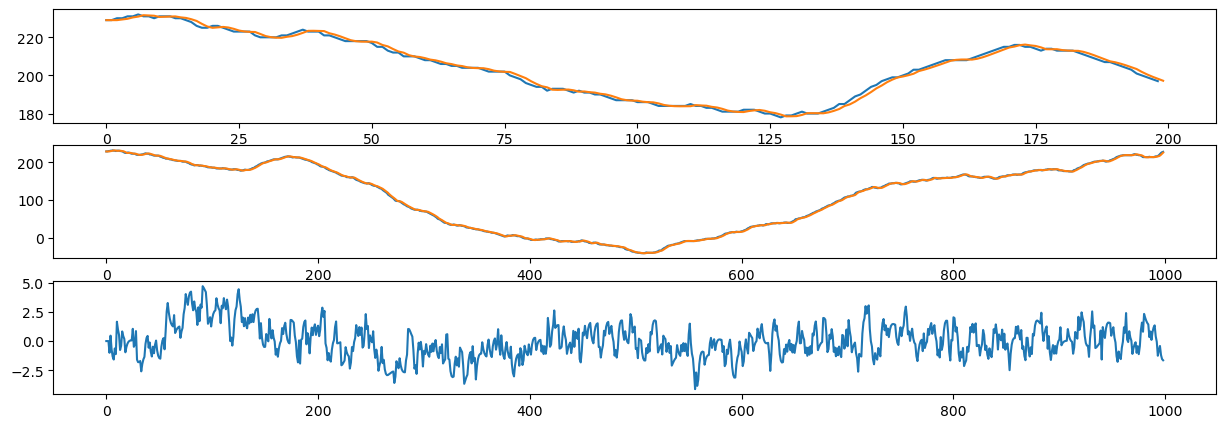

In [54]:
hurst = 1.0
traj = gen_traj(frame_num=1000, 
                ants_num=1, 
                frame_shape=(500, 500), 
                margin = -10,
                hurst_move = hurst,
                hurst_species = 0.5, 
                start_point = None)
kp = KalmanPredictorAR3()
kf_dict = {}
for tid in range(traj.shape[1]):
    kf_dict[tid] = kp._init_kf(traj[0, tid], hurst=hurst)


predictions = defaultdict(list)
for tid in range(traj.shape[1]):
    
    kf = kf_dict[tid]
    for detections in traj[1:, tid, :]:
        x_pred, y_pred, _, _, _, _, _, _ = kf.predict()
        kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
        predictions[tid].append([*x_pred, *y_pred])
        
kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))
rmse = np.mean(np.sqrt(np.mean((traj[1:]-kalman_preds)**2, axis=0)), axis=1)

fig, axes = plt.subplots(nrows=3)
axes = axes.flatten()
fig.set_size_inches((15, 5))
axes[0].plot(traj[1:200,0,0], label=f'fBm H:{hurst}')
axes[0].plot(kalman_preds[:200,0,0], label=f'fBm H:{hurst}')
axes[1].plot(traj[1:,0,0])
axes[1].plot(kalman_preds[:,0,0])
axes[2].plot(traj[1:,0,1]-kalman_preds[:,0,1])

plt.show()


## AR rmse plots

In [55]:
# fig_box, axes = plt.subplots(nrows=1)
# fig_box.set_size_inches((20,10))
# sns.boxplot(hurst_df_ar1.iloc[:, :16], native_scale=True, color='green', fill=False, linewidth=.75, showfliers=False, ax=axes)
# axes.plot(hurst_df_ar1.iloc[:, :16].median(), linestyle = '--', color='green')

# sns.boxplot(hurst_df_ar2.iloc[:, :16], native_scale=True, color='red', fill=False, linewidth=.75, showfliers=False,ax=axes)
# axes.plot(hurst_df_ar2.iloc[:, :16].median(), linestyle = '--', color='red')

# sns.boxplot(hurst_df_ar3.iloc[:, :16], native_scale=True, color='xkcd:sky blue', fill=False, linewidth=.75, showfliers=False,ax=axes)
# axes.plot(hurst_df_ar3.iloc[:, :16].median(), linestyle = '--', color='blue')

# sns.boxplot(hurst_df_cv.iloc[:, :16], native_scale=True, color='cyan', fill=False, linewidth=.75, showfliers=False,ax=axes)
# axes.plot(hurst_df_cv.iloc[:, :16].median(), linestyle = '--', color='cyan')
# # ax.set_xlabel('H') for ax in axes
# plt.ylabel('RMSE')
# plt.xlabel('H')
# plt.grid()

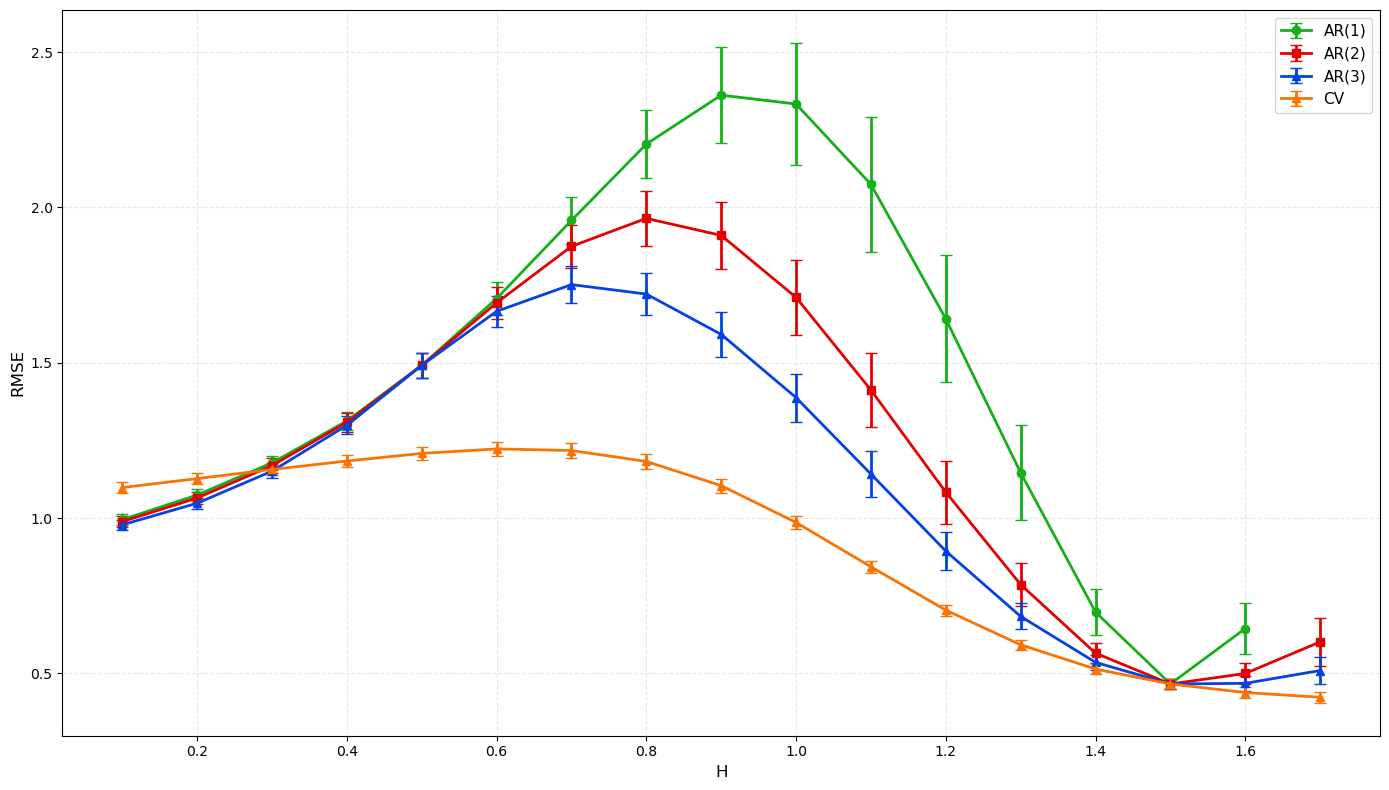

In [56]:
fig_box, axes = plt.subplots(figsize=(14, 8))
h_max = 17
x_pos = hurst_df_ar1.columns[:h_max].to_list()
width = 0.25

# AR1
means_ar1 = hurst_df_ar1.iloc[:, :h_max].mean()
std_ar1 = hurst_df_ar1.iloc[:, :h_max].std()
axes.errorbar(x_pos, means_ar1, yerr=std_ar1, fmt='o-', 
              label='AR(1)', color='xkcd:green', linewidth=2, markersize=6, capsize=4)

# # AR1 incorrect
# means_ar1_bad = hurst_df_ar1_bad.iloc[:, :15].mean()
# std_ar1_bad = hurst_df_ar1_bad.iloc[:, :15].std()
# axes.errorbar(x_pos, means_ar1_bad, yerr=std_ar1_bad, fmt='^-', 
#               label='AR1 incorr', color='xkcd:topaz', linewidth=2, markersize=6, capsize=4)

# AR2
means_ar2 = hurst_df_ar2.iloc[:, :h_max].mean()
std_ar2 = hurst_df_ar2.iloc[:, :h_max].std()
axes.errorbar(x_pos, means_ar2, yerr=std_ar2, fmt='s-', 
              label='AR(2)', color='xkcd:red', linewidth=2, markersize=6, capsize=4)

# AR3
means_ar3 = hurst_df_ar3.iloc[:, :h_max].mean()
std_ar3 = hurst_df_ar3.iloc[:, :h_max].std()
axes.errorbar(x_pos, means_ar3, yerr=std_ar3, fmt='^-', 
              label='AR(3)', color='xkcd:blue', linewidth=2, markersize=6, capsize=4)

# CV
means_cv = hurst_df_cv.iloc[:, :h_max].mean()
std_cv = hurst_df_cv.iloc[:, :h_max].std()
axes.errorbar(x_pos, means_cv, yerr=std_cv, fmt='^-', 
              label='CV', color='xkcd:orange', linewidth=2, markersize=6, capsize=4)




axes.set_xlabel('H', fontsize=12)
axes.set_ylabel('RMSE', fontsize=12)
# axes.set_xticks(x_pos)
# axes.set_xticklabels([f'H{i}' for i in range(16)])
axes.legend(fontsize=11, loc='best')
axes.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
# plt.savefig('../data/artifacts/rmse_vs_h_all_kalmans.png')
plt.show()


# track & eval

In [ ]:
def track(
    input_path: str,
    output_path: str = "tracked_output.mp4",
    csv_path: str = "tracks.csv",
    imshow=True,
    roi=None,
    dist2Threshold=50,
    knn_history = 100,
    pred_head = 'kalman',
    warmup_frames = 50,
    kasdin_hurst=1.2
):
    if pred_head=='zero': pred_head=None
    
    cap = cv.VideoCapture(input_path)

    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {input_path}")

    fps = cap.get(cv.CAP_PROP_FPS)
    width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
    if output_path is not None:
        fourcc = cv.VideoWriter_fourcc(*"mp4v")
        writer = cv.VideoWriter(output_path, fourcc, fps, (width, height))

    tracker = NMOT(
        warmup_frames=warmup_frames,
        dist2Threshold=dist2Threshold,
        knn_history=knn_history,
        min_area=8,
        max_area=80,
        max_match_dist=25,
        max_missed=12,
        pred_head=pred_head,
        roi=roi,
        kasdin_hurst=kasdin_hurst
    )

    while True:
        ok, frame = cap.read()

        if not ok:
            break

        vis, mask, active_tracks = tracker.update(frame)
        if output_path is not None: 
            writer.write(vis)

        if imshow:
            # cv2.imshow('frame', frame)
            fig, ax = plt.subplots(nrows=2)
            fig.set_size_inches((20, 10))
            
            ax[0].imshow(vis)
            ax[1].imshow(mask)
            
            plt.show()
            
            clear_output(wait=True)
            if cv.waitKey(1) & 0xFF == 27:
                cv.destroyAllWindows()
                if output_path:
                    writer.release()
                break

    cap.release()
    if output_path is not None: 
        writer.release()
    cv.destroyAllWindows()
    if csv_path:
        df = tracker.save_tracks(csv_path)

    # return df

In [ ]:
from tqdm import tqdm
from itertools import product
import numpy as np

ar_predheads = ['kalman_ar2', 'kalman_ar3']
ants_nums = [100, 300, 900]
seeds = np.arange(1, 50, 1, dtype=int)
warmup_frames = 30
total_iterations = len(ar_predheads) * len(ants_nums) * len(seeds)

for predhead, ants_num, seed in tqdm(
    product(ar_predheads, ants_nums, seeds),
    total=total_iterations,
    desc='Processing'
):
    track(
        input_path=f'../data/synth_collision_gt_{ants_num}/gt_{seed}.mp4',
        output_path=None,
        csv_path=f'../data/synth_collision_tracked_{ants_num}/tracked_{predhead}_{seed}.csv',
        dist2Threshold=200,
        knn_history=200,
        imshow=False,
        pred_head=predhead,
        warmup_frames=warmup_frames,
        kasdin_hurst=1.2
    )


In [4]:
from eval import evaluate_mot
def eval(gt_path, pred_path, warmup_frames:int, alpha_dist = 5.0):
    
    
    gt = pd.read_csv(gt_path)
    pred = pd.read_csv(pred_path)

    gt = gt.rename(columns={'ant_id':'track_id'})
    gt = gt[gt.frame >= warmup_frames]

    summary, accumulator = evaluate_mot(gt, pred, distance_threshold=alpha_dist)

    return summary

# AR one-proc eval

In [ ]:
warmup_frames = 30
metrics_dict = {}
alpha_dist = 5.0

ar_predheads = ['kalman_ar1', 'kalman_ar2', 'kalman_ar3']
ants_nums = [100, 300, 900]
seeds = np.arange(1, 50, 1, dtype=int)

total_iterations = len(ar_predheads) * len(ants_nums) * len(seeds)
tracked_csv_path = f'../data/synth_collision_tracked_{ants_num}/tracked_{predhead}_{seed}.csv'
total_dict = {}
for ants_num in ants_nums:
    seeds_dict = {}
    for seed in seeds:
        pred_head_result = []

        for predhead in ar_predheads:
            tracked_csv_path = f'../data/synth_collision_tracked_{ants_num}/tracked_{predhead}_{seed}.csv'
            gt_csv_path = f'../data/synth_collision_gt_{ants_num}/gt_{seed}.csv'
            summary = eval(gt_csv_path, tracked_csv_path, warmup_frames, alpha_dist=alpha_dist)
            pred_head_result.append(summary.T)

        metrics_df = pd.concat(pred_head_result, axis=1)
        metrics_df.columns = ar_predheads
        seeds_dict[seed] = metrics_df
        
    total_dict[ants_num] = seeds_dict

# AR parallel eval

In [8]:
from joblib import Parallel, delayed
import pandas as pd

warmup_frames = 30
alpha_dist = 5.0
ar_predheads = ['kalman_ar1', 'kalman_ar2', 'kalman_ar3']
ants_nums = [100, 300, 900]
seeds = np.arange(1, 50, 1, dtype=int)

def evaluate_seed(seed, ants_num, ar_predheads, warmup_frames, alpha_dist):
    """Evaluate all prediction heads for a single seed"""
    pred_head_result = []
    
    for predhead in ar_predheads:
        tracked_csv_path = f'../data/synth_collision_tracked_{ants_num}/tracked_{predhead}_{seed}.csv'
        gt_csv_path = f'../data/synth_collision_gt_{ants_num}/gt_{seed}.csv'
        summary = eval(gt_csv_path, tracked_csv_path, warmup_frames, alpha_dist=alpha_dist)
        pred_head_result.append(summary.T)
    
    metrics_df = pd.concat(pred_head_result, axis=1)
    metrics_df.columns = ar_predheads
    return metrics_df

total_dict = {}
for ants_num in ants_nums:
    # Parallelize across seeds
    results = Parallel(n_jobs=16)(  # -1 uses all available cores
        delayed(evaluate_seed)(seed, ants_num, ar_predheads, warmup_frames, alpha_dist)
        for seed in seeds
    )
    
    seeds_dict = {seed: result for seed, result in zip(seeds, results)}
    total_dict[ants_num] = seeds_dict


/home/akhiyarov/.conda/envs/asdc/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [9]:
import pickle
with open(f'../data/ar_predheads_montecarlo.pkl', 'wb') as f:
    pickle.dump(total_dict, f)